In [2]:
%load_ext autoreload
%autoreload 3


import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from explainit.priorities.nonlinear import exponential
from explainit.explainers.minlp_search import MINLSearchExplainer

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [3]:
# Example: Load German Credit dataset
df = pd.read_csv('data/german_credit_data.csv')  # Replace with your dataset path

# Improved preprocessing for your dataset

# Drop 'Unnamed: 0' as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Handle missing values in categorical columns by filling with 'missing'
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount','Duration']

df[cat_cols] = df[cat_cols].fillna('missing')

# Encode target: convert 'Risk' to binary (e.g., 'good' = 1, 'bad' = 0)
df['target'] = (df['Risk'] == 'good').astype(int)
df = df.drop(columns=['Risk'])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale numerical features
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X.index)
X = pd.concat([X[num_cols], X_cat], axis=1)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']


scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], X_cat], axis=1)
for col in encoder.get_feature_names_out(encoder.feature_names_in_):
    X[col] = X[col].astype('category')
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.76




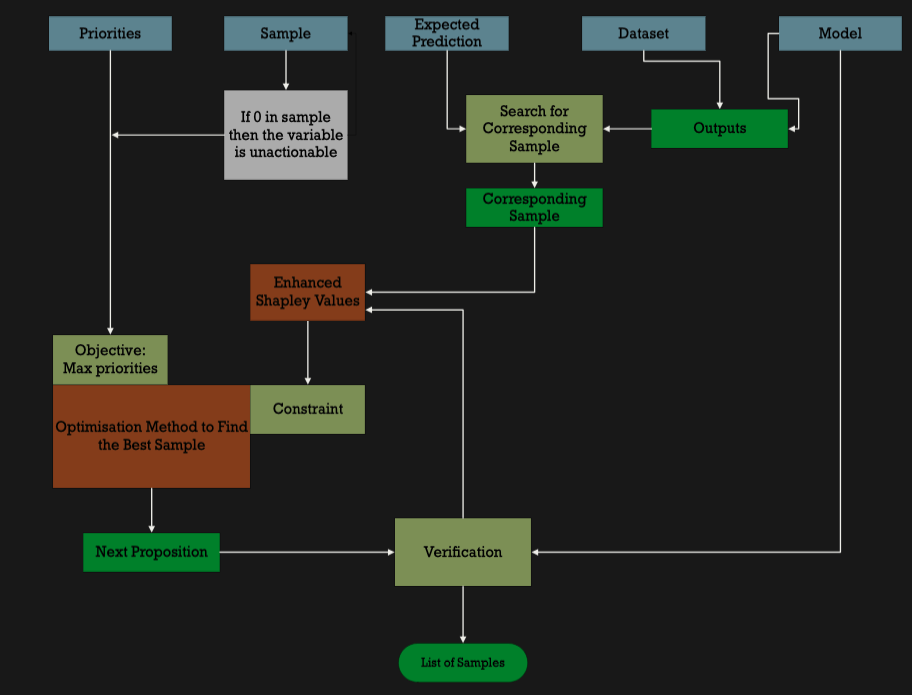

## 1. Select sample for analysis

In [4]:
sample = [                          # Features:
    0.69642857,                     # Age
    0.86359635,                     # Credit amount
    0.73529412,                     # Duration
    0., 1.,                         # Sex
    0., 0., 1., 0.,                 # Job
    0., 0., 1.,                     # Housing
    1., 0., 0., 0., 0.,             # Saving accounts
    0., 0., 1., 0.,                 # Checking account
    1., 0., 0., 0., 0., 0., 0., 0.  # Purpose
    ]

## 2. Select model and requested target
In this scenario, the requested target is probability of classification as class '1'. We want to get probability equal to $60\%$. Note, that we cannot use output of the model (model.predict), which output only $0$ or $1$. We need to use model.predict_proba available in LogisticRegression of SciKit-learn. In this case the output are two values: (probability of class '0', probability of class '1'). We are interested only in the latter, so we select $0.60$ as out requested target, meaning "probability of class '1'".

In [6]:
model_pred([sample])

array([0.3497378])

In [5]:
model_pred = lambda x: model.predict_proba(x)[:,1] # selecting output interesting for me
target = 0.60

## 3. Indicate barriers and priorities. 
By "barriers" we mean min/max values. By "priorities" we mean weight functions that indicate which values of features are preferable to us and which are not.

### Detailed instructions
The priorities need to be written in dictionary of such format:
```python
{
    'numerical':{
        index x: <priority value>,
        index y: <priority value>,
        ...
    }

    'categorical':{
        (index a1, index b1, ..., index n1) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        },
        (index a2, index b2, ..., index n2) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        }
        ...
    }
}
```

- Numerical (continuous) features:
  - unactionable : use int 0 instead of ```<priority value>```, this means that the value from the sample will be used and will not participate in selection based on priority
  - actionable: use ```{'function':<f(x)>,'min': <min value>, 'max': <max value>}```
    - replace ```<f(x)>``` with given function $f : [0, 1]$ 
    - replace ```<min value>``` and ```<max value>``` with respective values (floats or integers)
- Categorical features:
  - for given indices (index a1, index b1, ..., index n1) create dictionary mapping all possible categories to $0$ (don't use) or $1$ (can be used). The algorithm will then be able to use allowed categories and omit forbidden. You can also use other values than $1$ for permitted categories form range $(0, 1]$ to indicate priority. In this case, larger value makes the priority higher.

### Column names
The column names and indices in this example are as follows:
```python
'column': index

'Age': 0
'Credit amount': 1
'Duration': 2

'Sex_female': 3
'Sex_male': 4

'Job_0': 5
'Job_1': 6
'Job_2': 7
'Job_3':8

'Housing_free': 9
'Housing_own': 10
'Housing_rent': 11

'Saving accounts_little': 12
'Saving accounts_missing': 13
'Saving accounts_moderate': 14
'Saving accounts_quite rich': 15
'Saving accounts_rich': 16

'Checking account_little': 17
'Checking account_missing': 18
'Checking account_moderate': 19
'Checking account_rich': 20

'Purpose_business': 21
'Purpose_car': 22
'Purpose_domestic appliances': 23
'Purpose_education': 24
'Purpose_furniture/equipment': 25
'Purpose_radio/TV': 26
'Purpose_repairs': 27
'Purpose_vacation/others': 28
```

In [5]:
min_cred_am = 0.35 # 0.45 #0.65
max_cred_am = X.iloc[1,:].max()
min_duration = 0.30 # 0.40 #0.60
max_duration = X.iloc[2,:].max()

def cred_am_weight(x):
    return exponential(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def duration_weight(x):
    return exponential(x, x0=0.60, x1=0.73, increasing=True, a = 5)

priorities = {
    'numerical':{0: 0, # unactionable
                1: {'function':cred_am_weight,'min':min_cred_am, 'max':max_cred_am},
                2: {'function':duration_weight,'min':min_duration, 'max':max_duration}
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0): 1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}


# 4. I look for the sample that results in a prediction the closest to the specified target

In [ ]:
explainer = MINLSearchExplainer(model_pred, priorities, sample, target, dataset=X.values, closest_sample_epsilon=0.01)
# explainer.find_closest_elem(epsilon=0.01)

2025-11-03 12:37:40,226 - INFO - explainit - Finding the closest element in the dataset based on the specified priorities...


# 5. Calculate Shapley values between original and newly selected sample

In [ ]:
# Calculating Shapley values - how each features moved the prediction from the original sample to the "closest" one

# shap_vals = explainer.calc_shapley(r=explainer.sample)

# 6. Use Shapley values with priorities from point 3 and find the most optimal combination of variables 

In [8]:
counterfactuals = explainer.find_counterfactuals()

2025-11-03 12:38:39,511 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,511 - INFO - explainit - solution: None
2025-11-03 12:38:39,513 - INFO - explainit - linear_solution["success"]: True
2025-11-03 12:38:39,513 - INFO - explainit - solution: [0.39948104 0.3       ]
2025-11-03 12:38:39,513 - INFO - explainit - sample: [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,513 - INFO - explainit - dummy_x: [0.69642857, np.float64(0.39948104452752864), np.float64(0.3), 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,514 - INFO - explainit - constraint_function: 0.6
2025-11-03 12:38:39,517 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,517 - INFO - explainit - solution: None
2025-11-03 12:38:39,519 - IN

In [9]:
counterfactuals

[[np.float64(0.69642857),
  np.float64(0.39948104452752864),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.8711079530441714),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.35),
  np.float64(0.5808767421431051),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.3753359471325555),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
